In [8]:
%%writefile /kaggle/working/model.py
import torch.nn as nn
from torchvision import models


_MODEL_REGISTRY = {
    "efficientnet_b0": (models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1),
    "efficientnet_b3": (models.efficientnet_b3, models.EfficientNet_B3_Weights.IMAGENET1K_V1),
}


class HemorrhageEfficientNet(nn.Module):
    def __init__(self, num_classes: int = 6, pretrained: bool = True, dropout: float = 0.3,
                 variant: str = "efficientnet_b3"):
        super().__init__()

        if variant not in _MODEL_REGISTRY:
            raise ValueError(f"Unknown variant '{variant}'. Choose from {list(_MODEL_REGISTRY)}")
        constructor, weights_enum = _MODEL_REGISTRY[variant]
        weights = weights_enum if pretrained else None
        self.backbone = constructor(weights=weights)

        # in_features is read dynamically, so this works unchanged across variants
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)  # returns raw logits, shape (batch, num_classes)


def build_model(num_classes=6, pretrained=True, dropout=0.3, variant="efficientnet_b3", device=None):
    """Convenience factory used by train.py."""
    model = HemorrhageEfficientNet(num_classes, pretrained, dropout, variant)
    if device is not None:
        model = model.to(device)
    return model

Overwriting /kaggle/working/model.py


In [9]:
%%writefile /kaggle/working/train.py
import os
import copy
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import amp
from tqdm import tqdm
from losses import FocalLossWithLogits 

import config
from model import build_model
from data_loader import prepare_dataloaders
from metrics import (
    multilabel_accuracy,
    get_classification_report,
    plot_confusion_matrices,
    plot_training_curves,
)


def set_seed(seed: int):
    """For reproducibility across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    loop = tqdm(loader, desc="Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with amp.autocast(device_type=config.DEVICE.type, enabled=config.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(logits) > config.CLASSIFICATION_THRESHOLD).float()
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loop.set_postfix(batch_loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    _, mean_acc, _ = multilabel_accuracy(y_true, y_pred)
    return epoch_loss, mean_acc


@torch.no_grad()
def validate(model, loader, criterion, device, return_predictions: bool = False):
    """
    No-gradient evaluation pass. Note: augmentation is already disabled here
    because val_loader was built with get_val_transforms() in data_loader.py
    (resize + normalize only).
    """
    model.eval()
    running_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []

    loop = tqdm(loader, desc="Val", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        with amp.autocast(device_type=config.DEVICE.type, enabled=config.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > config.CLASSIFICATION_THRESHOLD).float()

        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        loop.set_postfix(batch_loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    _, mean_acc, _ = multilabel_accuracy(y_true, y_pred)

    if return_predictions:
        y_prob = np.concatenate(all_probs)
        return epoch_loss, mean_acc, y_true, y_pred, y_prob
    return epoch_loss, mean_acc


def main():
    set_seed(config.SEED)
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    print(f"Using device: {config.DEVICE}")

    # Data
    df = pd.read_csv(config.METADATA_CSV)
    train_loader, val_loader, test_loader, alpha = prepare_dataloaders(
        df=df,
        img_dir=config.PNG_DIR,
        batch_size=config.BATCH_SIZE,
        num_workers=config.NUM_WORKERS,
        img_size=config.IMG_SIZE,
        patient_col=config.PATIENT_ID_COL,
        label_cols=config.LABEL_COLS,
    )

    # Model
    model = build_model(
        num_classes=config.NUM_CLASSES,
        pretrained=config.PRETRAINED,
        dropout=config.DROPOUT,
        variant=config.MODEL_VARIANT,
        device=config.DEVICE,
    )

    # Loss / Optimizer / Scheduler
    criterion = FocalLossWithLogits(alpha=alpha.to(config.DEVICE), gamma=config.FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    scaler = amp.GradScaler('cuda', enabled=(config.USE_AMP and config.DEVICE.type == 'cuda'))

    # Training loop
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(1, config.EPOCHS + 1):
        print(f"\nEpoch {epoch}/{config.EPOCHS}")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, config.DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            ckpt_path = os.path.join(config.CHECKPOINT_DIR, "best_model.pth")
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> New best model saved to {ckpt_path}")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= config.PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    # Restore best weights before final evaluation 
    model.load_state_dict(best_model_wts)

    # Plot loss & accuracy curves
    plot_training_curves(history, save_path=os.path.join(config.RESULTS_DIR, "training_curves.png"))

    # Save per-epoch history to CSV
    history_df = pd.DataFrame(history)
    history_df.index.name = "epoch"
    history_df.index += 1
    history_df.to_csv(os.path.join(config.RESULTS_DIR, "training_history.csv"))
    
    # Final classification report + confusion matrices (on val set)
    val_loss, val_acc, y_true, y_pred, y_prob = validate(
        model, val_loader, criterion, config.DEVICE, return_predictions=True
    )

    report = get_classification_report(y_true, y_pred, config.LABEL_COLS)
    print("\nClassification Report (Validation Set):\n")
    print(report)
    with open(os.path.join(config.RESULTS_DIR, "classification_report.txt"), "w") as f:
        f.write(report)

    plot_confusion_matrices(
        y_true, y_pred, config.LABEL_COLS,
        save_path=os.path.join(config.RESULTS_DIR, "confusion_matrices.png"),
    )

    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    print(f"Results saved to: {config.RESULTS_DIR}/")
    print(f"Best checkpoint saved to: {config.CHECKPOINT_DIR}/best_model.pth")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/train.py


In [10]:
%%writefile /kaggle/working/config.py
import torch

PNG_DIR = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_dataset_png/rsna_dataset_png"
METADATA_CSV = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_metadata.csv"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
RESULTS_DIR = "/kaggle/working/results"

# Data

IMG_SIZE = 384
BATCH_SIZE = 16     
NUM_WORKERS = 2
PATIENT_ID_COL = "PatientID"

# Model

NUM_CLASSES = 6
LABEL_COLS = ['any', 'epidural', 'intraparenchymal',
              'intraventricular', 'subarachnoid', 'subdural']
DROPOUT = 0.3
PRETRAINED = True  
MODEL_VARIANT = "efficientnet_b3"

# Training

EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 5                      
CLASSIFICATION_THRESHOLD = 0.5   
USE_AMP = True                    
SEED = 42
FOCAL_GAMMA = 2.0 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Overwriting /kaggle/working/config.py


In [11]:
%%writefile /kaggle/working/data_loader.py
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold

# Augmentation Pipelines
def get_train_transforms(img_size: int = 384) -> A.Compose:
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.05, 0.05),
            rotate=(-12, 12),
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.1, 
            contrast_limit=0.1, 
            p=0.4
        ),
        A.Resize(height=img_size, width=img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_val_transforms(img_size: int = 384) -> A.Compose:
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

class RSNADataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
        # Target label columns
        self.label_cols = ['any', 'epidural', 'intraparenchymal', 
                           'intraventricular', 'subarachnoid', 'subdural']
        
        # Pre-extract label matrix as float32 numpy array for faster indexing
        self.labels = self.df[self.label_cols].values.astype(np.float32)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        img_id = self.df.iloc[idx]['Image_ID']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found at path: {img_path}")
            
        # convert to RGB for OpenCV
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply Augmentation + Normalization + ToTensor
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

# 3. Train/Val/Test Split & DataLoader Helper
def prepare_dataloaders(
    df: pd.DataFrame,
    img_dir: str,
    batch_size: int = 32,
    num_workers: int = 4,
    img_size: int = 384,
    patient_col: str = "PatientID",
    label_cols: list = None,
):
    y = df['any']
    groups = df[patient_col]

    # Train (80%) vs Temp (20%) — grouped by patient, stratified by 'any'
    sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, temp_idx = next(sgkf_outer.split(df, y, groups))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    # Temp -> Val (10%) / Test (10%) — grouped by patient, stratified by 'any'
    sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
    val_idx, test_idx = next(sgkf_inner.split(temp_df, temp_df['any'], temp_df[patient_col]))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    # Sanity check: no patient should appear in more than one split
    train_p, val_p, test_p = set(train_df[patient_col]), set(val_df[patient_col]), set(test_df[patient_col])
    assert not (train_p & val_p) and not (train_p & test_p) and not (val_p & test_p), \
        "Patient leakage detected across splits!"

    print(f"Dataset Split Summary:")
    print(f" - Train samples: {len(train_df)} ({len(train_p)} patients)")
    print(f" - Val samples:   {len(val_df)} ({len(val_p)} patients)")
    print(f" - Test samples:  {len(test_df)} ({len(test_p)} patients)")

    train_dataset = RSNADataset(train_df, img_dir, transform=get_train_transforms(img_size))
    val_dataset   = RSNADataset(val_df, img_dir, transform=get_val_transforms(img_size))
    test_dataset  = RSNADataset(test_df, img_dir, transform=get_val_transforms(img_size))

    use_pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=use_pin
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin
    )
    alpha = compute_alpha(train_df, label_cols)
    
    return train_loader, val_loader, test_loader, alpha

def compute_alpha(df: pd.DataFrame, label_cols: list) -> torch.Tensor:
    """
    alpha[i] = fraction of negative samples for label i (neg_count / total).
    Used by focal loss to up-weight the rarer positive class per label —
    a label with few positives gets an alpha close to 1.
    """
    pos_counts = df[label_cols].sum().values
    total = len(df)
    alpha = (total - pos_counts) / total
    return torch.tensor(alpha, dtype=torch.float32)

Overwriting /kaggle/working/data_loader.py


In [12]:
%%writefile /kaggle/working/metrics.py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix


def multilabel_accuracy(y_true: np.ndarray, y_pred: np.ndarray):
    """
    y_true, y_pred: arrays of shape (n_samples, n_labels), values in {0, 1}.
    Returns: (subset_accuracy, mean_per_label_accuracy, per_label_accuracy_array)
    """
    subset_acc = (y_true == y_pred).all(axis=1).mean()
    per_label_acc = (y_true == y_pred).mean(axis=0)
    mean_label_acc = per_label_acc.mean()
    return subset_acc, mean_label_acc, per_label_acc


def get_classification_report(y_true: np.ndarray, y_pred: np.ndarray, label_cols: list) -> str:
    """
    Returns sklearn's per-class precision/recall/F1 report (as a string),
    treating each of the 6 labels as an independent binary classification task.
    """
    return classification_report(y_true, y_pred, target_names=label_cols, zero_division=0)


def plot_confusion_matrices(y_true: np.ndarray, y_pred: np.ndarray, label_cols: list, save_path: str = None):
    """
    Plots one 2x2 confusion matrix per label (multilabel_confusion_matrix
    computes a separate binary confusion matrix per class, since a single
    NxN matrix doesn't make sense when labels aren't mutually exclusive).
    """
    cms = multilabel_confusion_matrix(y_true, y_pred)
    n = len(label_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, (cm, name) in enumerate(zip(cms, label_cols)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        axes[i].set_title(name)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_curves(history: dict, save_path: str = None):
    """
    history: dict with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc',
    each a list of per-epoch values (produced by train.py).
    """
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCE Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train Acc (mean per-label)', marker='o')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc (mean per-label)', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Overwriting /kaggle/working/metrics.py


In [13]:
%%writefile /kaggle/working/losses.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLossWithLogits(nn.Module):
    """
    Multi-label sigmoid focal loss (Lin et al., 2017), adapted for BCE-style
    multi-label targets. Operates on raw logits, like BCEWithLogitsLoss.

    alpha: optional per-class tensor, shape (num_classes,). Weights the positive
           class per label — higher alpha for rarer positive labels.
    gamma: focusing parameter. Higher gamma down-weights already-easy
           (confidently correct) examples, forcing the model to focus on
           hard/misclassified ones. gamma=0 reduces to plain (weighted) BCE.
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)  # prob assigned to the true class
        focal_term = (1 - pt) ** self.gamma
        loss = focal_term * bce

        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

Overwriting /kaggle/working/losses.py


Using device: cuda
Dataset Split Summary:
 - Train samples: 60485 (14722 patients)
 - Val samples:   7471 (1838 patients)
 - Test samples:  7323 (1828 patients)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 159MB/s] 



Epoch 1/50


  Train Loss: 0.0095 | Train Acc: 0.8271
  Val   Loss: 0.0078 | Val   Acc: 0.8197
  -> New best model saved to /kaggle/working/checkpoints/best_model.pth

Epoch 2/50


  Train Loss: 0.0073 | Train Acc: 0.8834
  Val   Loss: 0.0067 | Val   Acc: 0.8916
  -> New best model saved to /kaggle/working/checkpoints/best_model.pth

Epoch 3/50


...

  Train Loss: 0.0057 | Train Acc: 0.9102
  Val   Loss: 0.0067 | Val   Acc: 0.9287
  -> No improvement for 1 epoch(s)

Epoch 5/50


  Train Loss: 0.0052 | Train Acc: 0.9161
  Val   Loss: 0.0071 | Val   Acc: 0.9356
  -> No improvement for 2 epoch(s)

Epoch 6/50


  Train Loss: 0.0048 | Train Acc: 0.9221
  Val   Loss: 0.0074 | Val   Acc: 0.9297
  -> No improvement for 3 epoch(s)

Epoch 7/50


  Train Loss: 0.0037 | Train Acc: 0.9365
  Val   Loss: 0.0085 | Val   Acc: 0.9367
  -> No improvement for 4 epoch(s)

Epoch 8/50


  Train Loss: 0.0034 | Train Acc: 0.9409
  Val   Loss: 0.0091 | Val   Acc: 0.9350
  -> No improvement for 5 epoch(s)
Early stopping triggered at epoch 8.


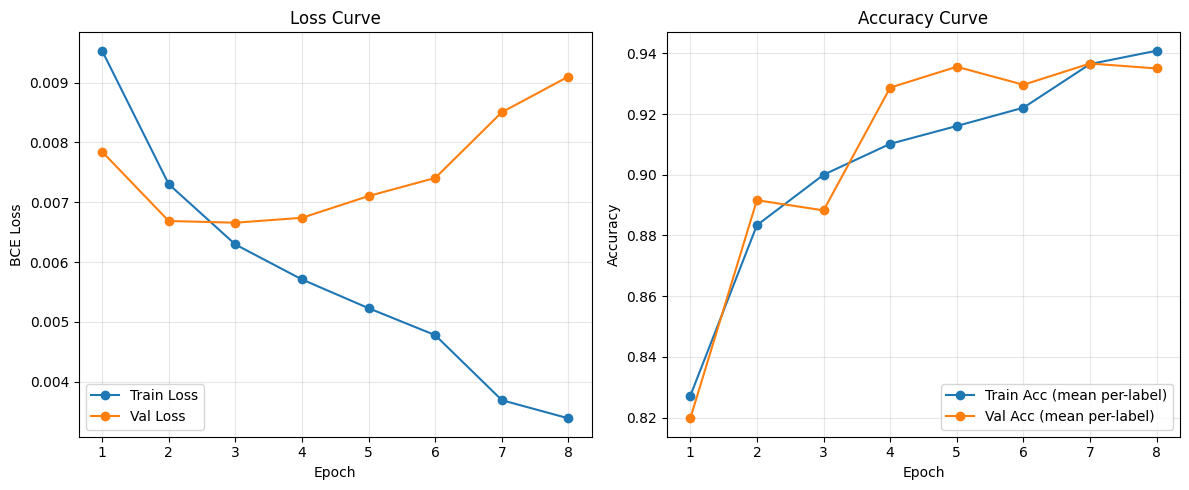


Classification Report (Validation Set):

                  precision    recall  f1-score   support

             any       0.59      0.91      0.72      1082
        epidural       0.02      0.92      0.05        24
intraparenchymal       0.35      0.94      0.51       361
intraventricular       0.33      0.97      0.49       272
    subarachnoid       0.23      0.89      0.37       361
        subdural       0.31      0.91      0.46       471

       micro avg       0.33      0.92      0.49      2571
       macro avg       0.31      0.92      0.43      2571
    weighted avg       0.42      0.92      0.56      2571
     samples avg       0.08      0.13      0.10      2571



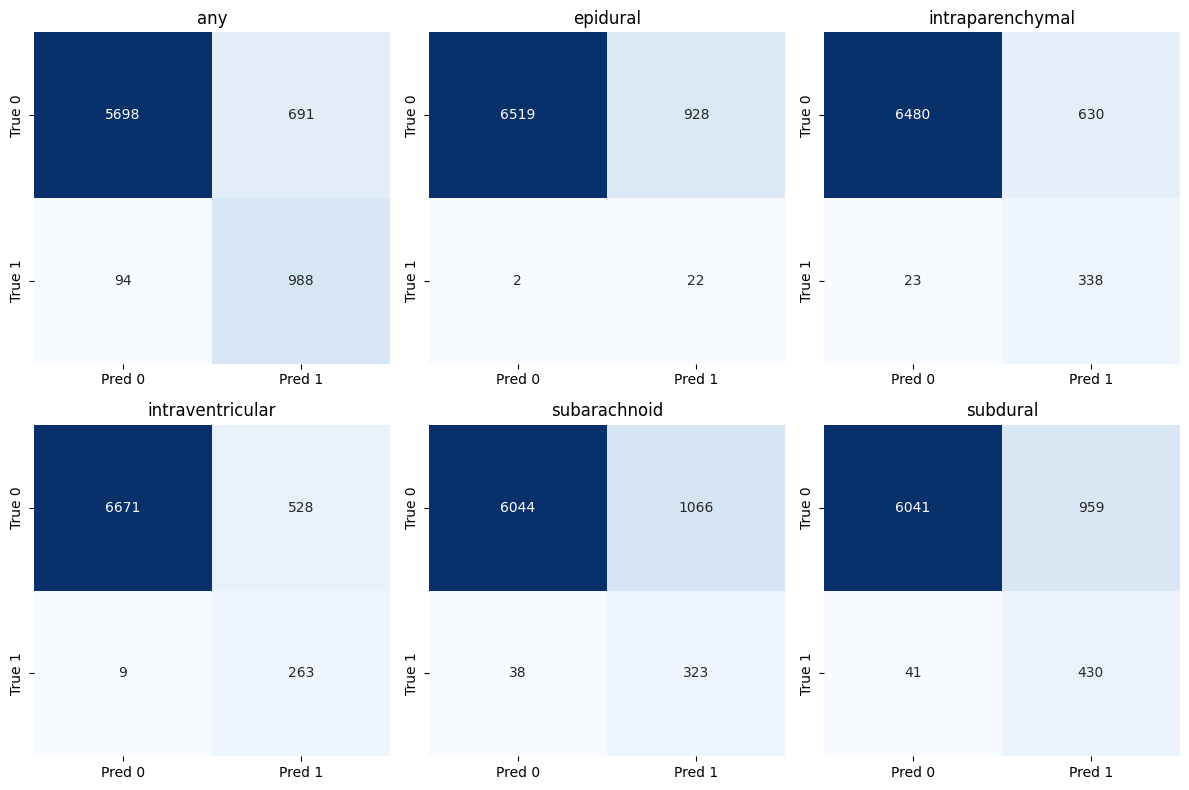


Training complete. Best val loss: 0.0067
Results saved to: /kaggle/working/results/
Best checkpoint saved to: /kaggle/working/checkpoints/best_model.pth


In [14]:
from train import main
main()

### Evaluation on test set

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)

import config
from model import build_model
from data_loader import prepare_dataloaders

# =========================================================
# Load data
# =========================================================

df = pd.read_csv(config.METADATA_CSV)

_, _, test_loader, _ = prepare_dataloaders(
    df=df,
    img_dir=config.PNG_DIR,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    img_size=config.IMG_SIZE,
    patient_col=config.PATIENT_ID_COL,
    label_cols=config.LABEL_COLS,
)

# =========================================================
# Load best model
# =========================================================

model = build_model(
    num_classes=config.NUM_CLASSES,
    pretrained=config.PRETRAINED,
    dropout=config.DROPOUT,
    variant=config.MODEL_VARIANT,
    device=config.DEVICE,
)


checkpoint_path = os.path.join(
    config.CHECKPOINT_DIR,
    "best_model.pth",
)


model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=config.DEVICE,
        weights_only=False,
    )
)

model.eval()

print("Loaded:", checkpoint_path)
print(f"Decision Threshold = {config.CLASSIFICATION_THRESHOLD:.2f}")

# =========================================================
# Predict on TEST SET
# =========================================================
from tqdm import tqdm

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(config.DEVICE)

        logits = model(images)

        probs = torch.sigmoid(logits)

        preds = (
            probs > config.CLASSIFICATION_THRESHOLD
        ).float()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

results_dir = config.RESULTS_DIR
os.makedirs(results_dir, exist_ok=True)

# =========================================================
# Classification Report
# =========================================================

report = classification_report(
    all_labels,
    all_preds,
    target_names=config.LABEL_COLS,
    digits=4,
    zero_division=0,
)

print("\nClassification Report\n")
print(report)

with open(
    os.path.join(
        results_dir,
        "classification_report_test.txt",
    ),
    "w",
) as f:
    f.write(report)

# =========================================================
# Confusion Matrices
# =========================================================

cms = multilabel_confusion_matrix(
    all_labels,
    all_preds,
)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

axes = axes.flatten()

for i, label in enumerate(config.LABEL_COLS):

    disp = ConfusionMatrixDisplay(cms[i])

    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )

    axes[i].set_title(label)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "confusion_matrices_test.png",
    ),
    dpi=300,
)

plt.show()

# =========================================================
# Precision-Recall Curves
# =========================================================

plt.figure(figsize=(8,6))

pr_auc = {}

for i, label in enumerate(config.LABEL_COLS):

    precision, recall, _ = precision_recall_curve(
        all_labels[:, i],
        all_probs[:, i],
    )

    ap = average_precision_score(
        all_labels[:, i],
        all_probs[:, i],
    )

    pr_auc[label] = ap

    plt.plot(
        recall,
        precision,
        label=f"{label} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "precision_recall_curves_test.png",
    ),
    dpi=300,
)

plt.show()

# =========================================================
# PR-AUC Table
# =========================================================

print("\nPR-AUC Scores (TEST SET)\n")

for label, score in pr_auc.items():
    print(f"{label:20s}: {score:.4f}")

pd.DataFrame({
    "Class": list(pr_auc.keys()),
    "PR-AUC": list(pr_auc.values()),
}).to_csv(
    os.path.join(
        results_dir,
        "pr_auc_scores_test.csv",
    ),
    index=False,
)

print("\nResults saved to:", results_dir)